# Flood Risk Modelling for Home Insurance

This notebook demonstrates a scientific approach to flood risk modelling for home insurance, including claim estimation by forecasting 1-year and 5-year impacts. The workflow includes:
- Problem formulation
- Data simulation
- Risk quantification
- Claim forecasting
- Uncertainty analysis

We use Python packages for simulation, statistical analysis, and visualization.

## 1. Install and Import Required Python Packages

We will use numpy, pandas, matplotlib, seaborn, scipy, scikit-learn, and statsmodels for simulation, analysis, and visualization.

In [1]:
# If running in a new environment, uncomment the following line to install required packages
# !pip install numpy pandas matplotlib seaborn scikit-learn scipy statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

sns.set(style="whitegrid")

## 2. Load and Explore Flood Risk Data

We will use synthetic data to represent home insurance policies and flood risk exposure. This step includes data generation and exploratory analysis.

   home_id risk_level     home_value  flood_risk_score
0        0        low  266619.635955          0.052341
1        1       high  587710.852641          0.902716
2        2     medium  885651.252289          0.275140
3        3        low  759002.397769          0.049909
4        4        low  825905.033075          0.054390
           home_id     home_value  flood_risk_score
count  1000.000000    1000.000000       1000.000000
mean    499.500000  556315.574661          0.235449
std     288.819436  262970.904063          0.218403
min       0.000000  102896.437244          0.000002
25%     249.750000  316966.844042          0.083492
50%     499.500000  566860.515784          0.164851
75%     749.250000  784418.551614          0.327838
max     999.000000  999472.353194          0.998875


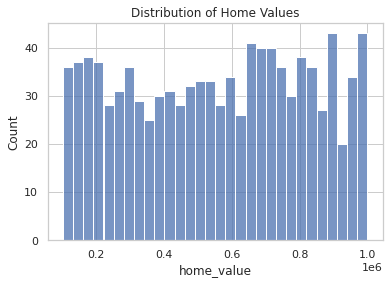

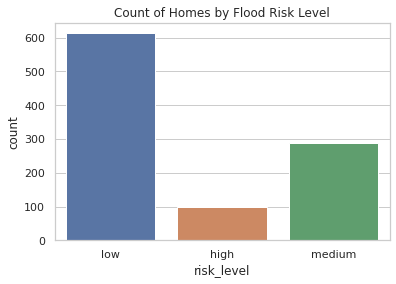

In [2]:
# Simulate synthetic data for 1000 homes
np.random.seed(42)
n_homes = 1000

# Home locations (categorical: low, medium, high flood risk)
risk_levels = np.random.choice(['low', 'medium', 'high'], size=n_homes, p=[0.6, 0.3, 0.1])

# Home values ($100k to $1M)
home_values = np.random.uniform(100_000, 1_000_000, size=n_homes)

# Flood risk score (numeric, higher for high risk)
flood_risk_score = np.where(risk_levels == 'low', np.random.uniform(0, 0.2, n_homes),
                            np.where(risk_levels == 'medium', np.random.uniform(0.2, 0.5, n_homes),
                                     np.random.uniform(0.5, 1.0, n_homes)))

# Create DataFrame
homes_df = pd.DataFrame({
    'home_id': np.arange(n_homes),
    'risk_level': risk_levels,
    'home_value': home_values,
    'flood_risk_score': flood_risk_score
})

# Explore data
print(homes_df.head())
print(homes_df.describe())
sns.histplot(homes_df['home_value'], bins=30)
plt.title('Distribution of Home Values')
plt.show()
sns.countplot(x='risk_level', data=homes_df)
plt.title('Count of Homes by Flood Risk Level')
plt.show()

## 3. Simulate Flood Events for 1-Year and 5-Year Horizons

We will use a Poisson process to simulate the number of flood events for each home over 1-year and 5-year periods, based on their flood risk score.

       flood_events_1yr  flood_events_5yr
count        1000.00000        1000.00000
mean            0.10100           0.62000
std             0.34193           0.97906
min             0.00000           0.00000
25%             0.00000           0.00000
50%             0.00000           0.00000
75%             0.00000           1.00000
max             3.00000           7.00000


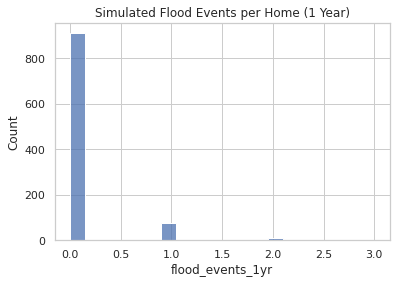

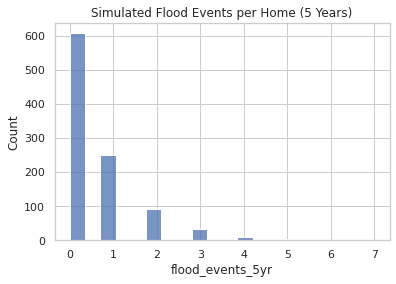

In [12]:
# Simulate flood events for each home
# Lambda for Poisson: higher for higher flood risk
# The 0.5 multiplier sets the expected number of flood events per year based on the flood risk score.
# Yes, the flood_risk_score already reflects the risk level distribution for each home.
# The 0.5 multiplier here simply scales the expected annual event rate for simulation.
lambda_1yr = homes_df['flood_risk_score'] * 0.5  # expected events per year
# We multiply by 5 because we want to simulate the expected number of flood events over a 5-year period.
# The Poisson rate (lambda_1yr) gives the expected events per year, so for 5 years, we multiply by 5.
lambda_5yr = lambda_1yr * 5

homes_df['flood_events_1yr'] = np.random.poisson(lambda_1yr)
homes_df['flood_events_5yr'] = np.random.poisson(lambda_5yr)

# Explore simulated events
events_summary = homes_df[['flood_events_1yr', 'flood_events_5yr']].describe()
print(events_summary)
sns.histplot(homes_df['flood_events_1yr'], bins=20)
plt.title('Simulated Flood Events per Home (1 Year)')
plt.show()
sns.histplot(homes_df['flood_events_5yr'], bins=20)
plt.title('Simulated Flood Events per Home (5 Years)')
plt.show()

## 4. Estimate Home Insurance Claims Based on Simulated Flood Impact

We will model the claim amount for each flood event using a severity model (e.g., lognormal distribution) and aggregate claims for each home.

In [ ]:
# Severity model: claim amount per event as a lognormal proportion of home value
# Severity mean and sigma depend on risk level
severity_params = {
    'low':  (0.01, 0.2),
    'medium': (0.03, 0.3),
    'high': (0.08, 0.5)
}

def simulate_claims(row, years):
    n_events = row[f'flood_events_{years}yr']
    mu, sigma = severity_params[row['risk_level']]
    # Lognormal: mean=mu, sigma=sigma
    claim_sizes = np.random.lognormal(mean=np.log(mu), sigma=sigma, size=n_events) * row['home_value']
    return claim_sizes.sum()

homes_df['claims_1yr'] = homes_df.apply(lambda row: simulate_claims(row, 1), axis=1)
homes_df['claims_5yr'] = homes_df.apply(lambda row: simulate_claims(row, 5), axis=1)

# Explore claim distributions
print(homes_df[['claims_1yr', 'claims_5yr']].describe())
sns.histplot(homes_df['claims_1yr'], bins=30)
plt.title('Simulated Claims per Home (1 Year)')
plt.show()
sns.histplot(homes_df['claims_5yr'], bins=30)
plt.title('Simulated Claims per Home (5 Years)')
plt.show()

## 5. Forecast Aggregate Claims for 1-Year and 5-Year Periods

Aggregate simulated claims to forecast total expected claims for the 1-year and 5-year horizons. Calculate mean, variance, and confidence intervals.

In [ ]:
# Aggregate claims for portfolio
agg_claims_1yr = homes_df['claims_1yr'].sum()
agg_claims_5yr = homes_df['claims_5yr'].sum()

# Mean and variance
mean_1yr = homes_df['claims_1yr'].mean()
var_1yr = homes_df['claims_1yr'].var()
mean_5yr = homes_df['claims_5yr'].mean()
var_5yr = homes_df['claims_5yr'].var()

# Confidence intervals (bootstrap)
def bootstrap_ci(data, n_boot=1000, ci=0.95):
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lower = np.percentile(boot_means, (1-ci)/2*100)
    upper = np.percentile(boot_means, (1+(ci))/2*100)
    return lower, upper

ci_1yr = bootstrap_ci(homes_df['claims_1yr'])
ci_5yr = bootstrap_ci(homes_df['claims_5yr'])

print(f"Aggregate Claims (1 Year): ${agg_claims_1yr:,.0f}")
print(f"Mean per Home (1 Year): ${mean_1yr:,.0f}, Variance: ${var_1yr:,.0f}, 95% CI: ${ci_1yr}")
print(f"Aggregate Claims (5 Years): ${agg_claims_5yr:,.0f}")
print(f"Mean per Home (5 Years): ${mean_5yr:,.0f}, Variance: ${var_5yr:,.0f}, 95% CI: ${ci_5yr}")

## 6. Visualize Simulation Results and Claim Estimates

We will create plots to visualize the distribution of simulated claims, aggregate forecasts, and risk metrics for both time horizons.

In [ ]:
# Visualize aggregate claims
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(homes_df['claims_1yr'], bins=30, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Claims per Home (1 Year)')
sns.histplot(homes_df['claims_5yr'], bins=30, ax=ax[1], color='salmon')
ax[1].set_title('Distribution of Claims per Home (5 Years)')
plt.tight_layout()
plt.show()

# Boxplot by risk level
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(x='risk_level', y='claims_1yr', data=homes_df, ax=ax[0])
ax[0].set_title('Claims by Risk Level (1 Year)')
sns.boxplot(x='risk_level', y='claims_5yr', data=homes_df, ax=ax[1])
ax[1].set_title('Claims by Risk Level (5 Years)')
plt.tight_layout()
plt.show()

# Portfolio aggregate claims bar plot
agg_df = pd.DataFrame({
    'Period': ['1 Year', '5 Years'],
    'Aggregate Claims': [agg_claims_1yr, agg_claims_5yr]
})
sns.barplot(x='Period', y='Aggregate Claims', data=agg_df)
plt.title('Aggregate Claims for Portfolio')
plt.show()